# 01 - Exploratory Data Analysis

**Vegetable Image Dataset** (`misrakahmed/vegetable-image-dataset`)

Goals:
- Load the dataset into a tidy data frame and summarise classes/images per split.
- Check class balance with a per-class distribution plot.
- Visualise sample images per class.
- Inspect image dimensions / aspect ratios to justify the CNN input size.

Every figure produced here is also saved to `reports/figures/` so the app can
display it later.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from PIL import Image

from src.config import FIGURES_DIR, SPLITS     # noqa: E402
from src.data import build_dataset_frame, dataset_stats  # noqa: E402

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
%matplotlib inline


In [2]:

df = build_dataset_frame()
stats = dataset_stats(df)
print(stats.to_string(index=False))
print(f"\nTotal images: {len(df):,}")
print("Classes:", ", ".join(sorted(df["class"].unique())))


     split  classes  images  images_per_class
     train       15   15000              1000
validation       15    3000               200
      test       15    3000               200

Total images: 21,000
Classes: Bean, Bitter_Gourd, Bottle_Gourd, Brinjal, Broccoli, Cabbage, Capsicum, Carrot, Cauliflower, Cucumber, Papaya, Potato, Pumpkin, Radish, Tomato


## 1) Image distribution across splits

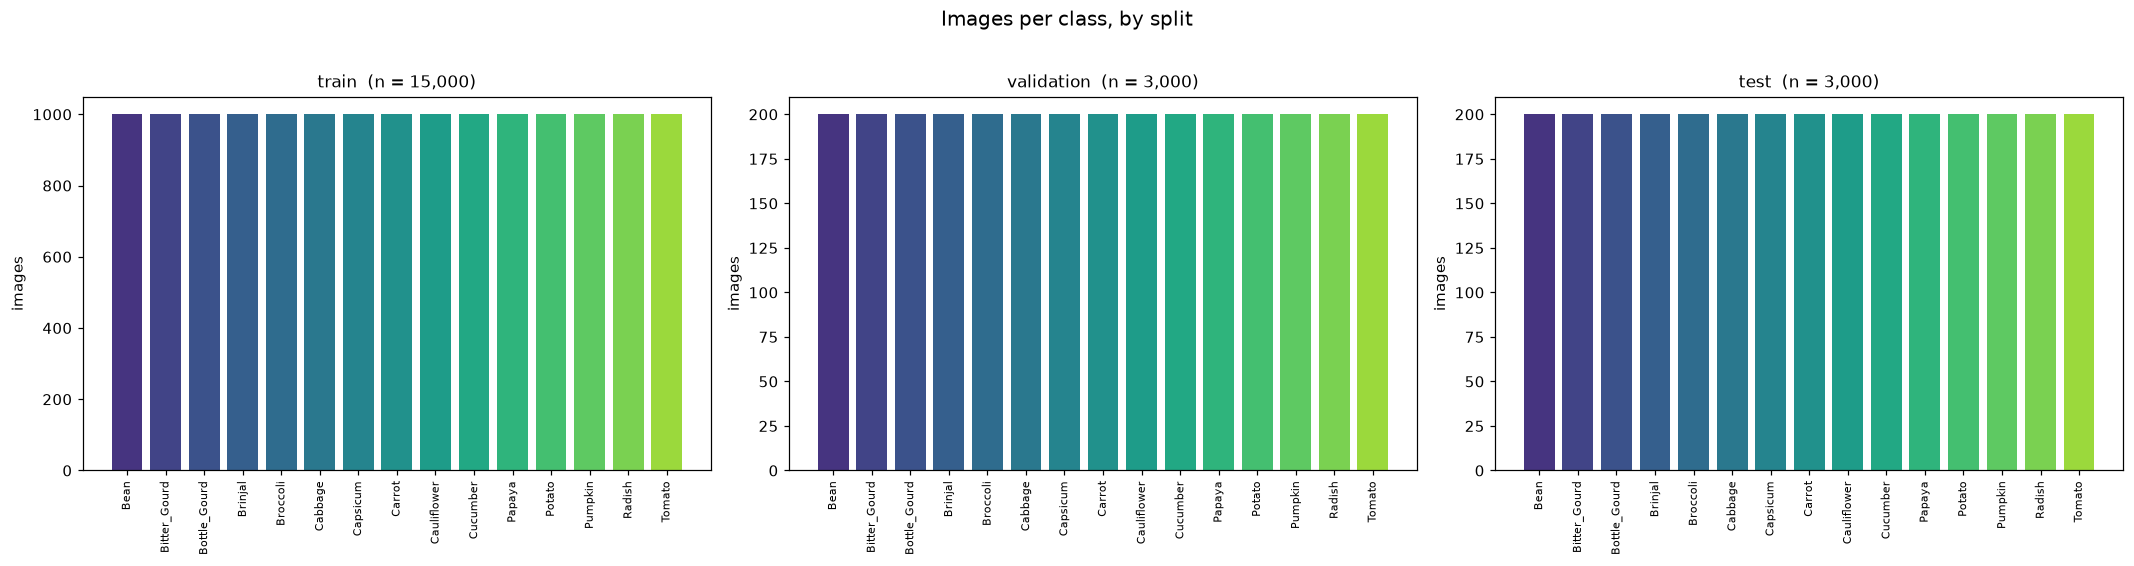

saved -> /mnt/hdd/projects/Vegetables-Classification/reports/figures/01_class_distribution.png


In [3]:

fig, axes = plt.subplots(1, len(stats), figsize=(6.5 * len(stats), 5))
for (_, row), ax in zip(stats.iterrows(), axes):
    counts = df[df["split"] == row["split"]]["class"].value_counts().sort_index()
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(counts)))
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(f"{row['split']}  (n = {counts.sum():,})", fontsize=11)
    ax.set_ylabel("images")
    ax.tick_params(axis="x", rotation=90, labelsize=7)

fig.suptitle("Images per class, by split", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"saved -> {FIGURES_DIR / '01_class_distribution.png'}")


## 2) Sample images per class (train split)

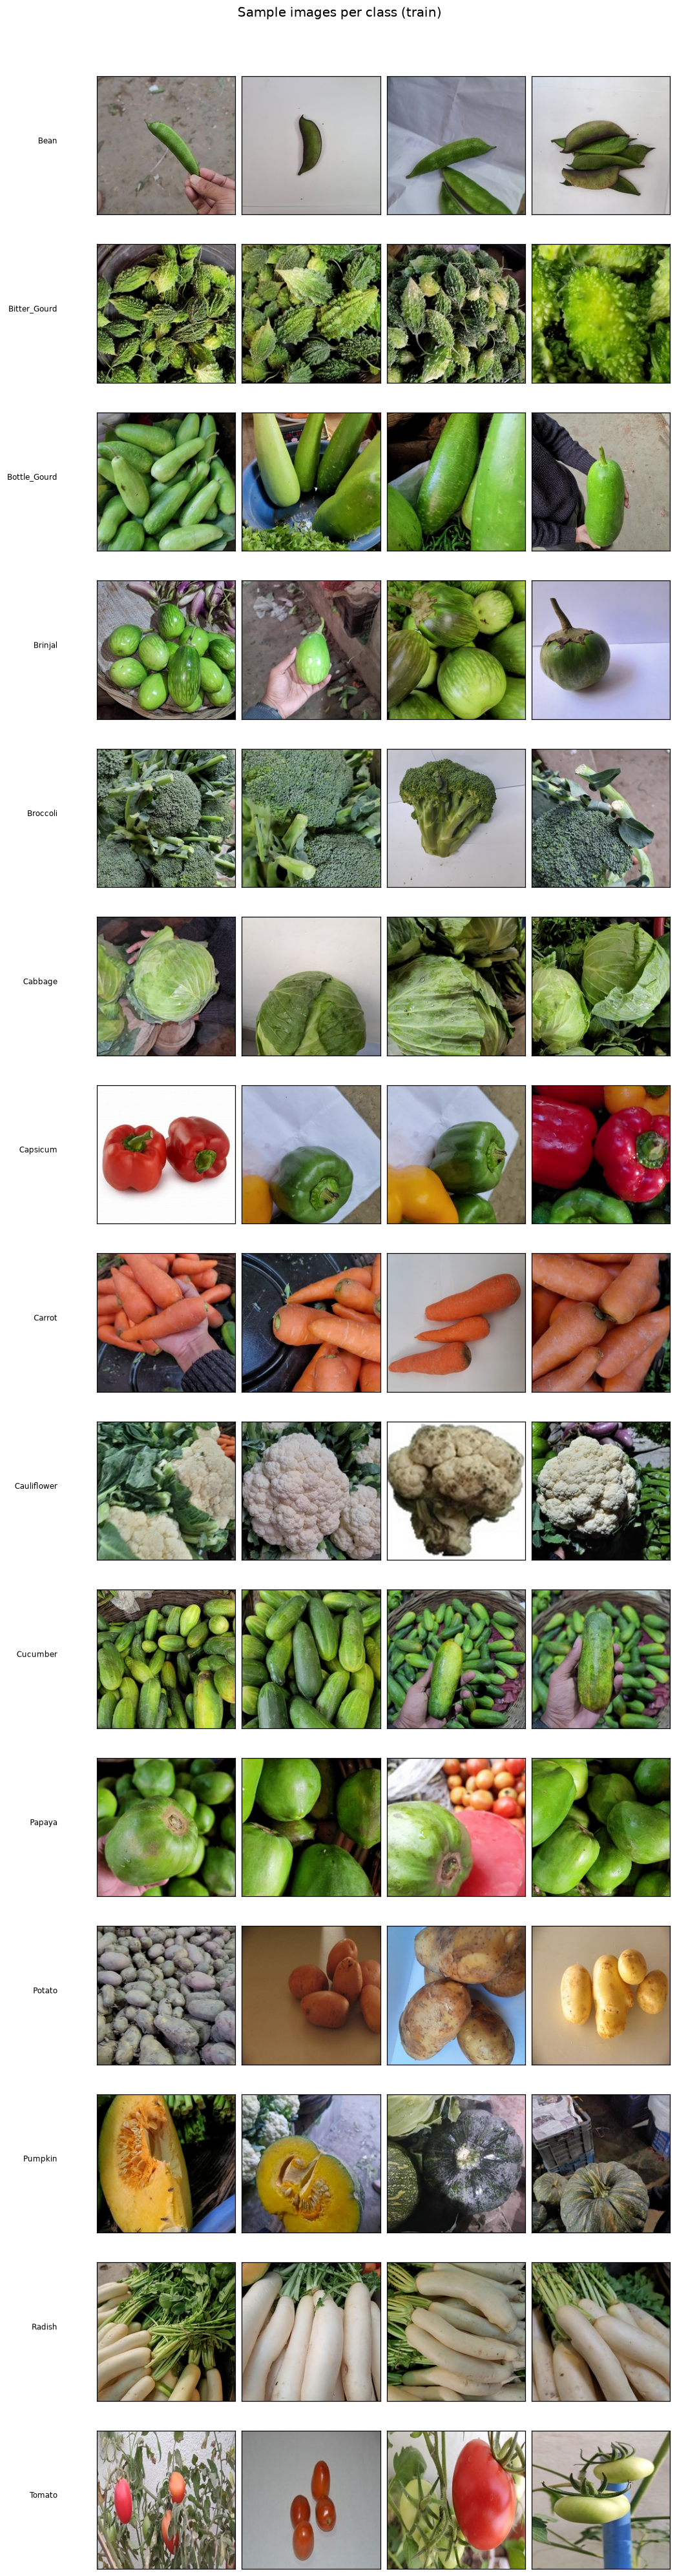

saved -> /mnt/hdd/projects/Vegetables-Classification/reports/figures/01_sample_images.png


In [4]:

SAMPLES_PER_CLASS = 4
classes = sorted(df[df["split"] == "train"]["class"].unique())
fig, axes = plt.subplots(
    len(classes), SAMPLES_PER_CLASS, figsize=(SAMPLES_PER_CLASS * 2.4, len(classes) * 2.4)
)

for i, cls in enumerate(classes):
    paths = df[(df["split"] == "train") & (df["class"] == cls)]["path"].head(SAMPLES_PER_CLASS)
    for j, p in enumerate(paths):
        ax = axes[i, j]
        ax.imshow(mpimg.imread(p))
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(cls, rotation=0, fontsize=8, labelpad=40, ha="right")

fig.suptitle("Sample images per class (train)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_sample_images.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"saved -> {FIGURES_DIR / '01_sample_images.png'}")


## 3) Image dimensions and aspect ratios

Reading every image size is slow (~21k images), so we sample up to 300 per split.

In [5]:

SAMPLE_PER_SPLIT = 300
sampled = pd.concat(
    [g.sample(min(SAMPLE_PER_SPLIT, len(g)), random_state=42) for _, g in df.groupby("split")]
)

size_rows = []
for split, cls, path in sampled[["split", "class", "path"]].itertuples(index=False, name=None):
    with Image.open(path) as im:
        w, h = im.size
    size_rows.append({"split": split, "width": w, "height": h})

dim = pd.DataFrame(size_rows)
dim["aspect_ratio"] = dim["width"] / dim["height"]
print(dim[["width", "height", "aspect_ratio"]].describe().to_string())


       width  height  aspect_ratio
count  900.0   900.0         900.0
mean   224.0   224.0           1.0
std      0.0     0.0           0.0
min    224.0   224.0           1.0
25%    224.0   224.0           1.0
50%    224.0   224.0           1.0
75%    224.0   224.0           1.0
max    224.0   224.0           1.0


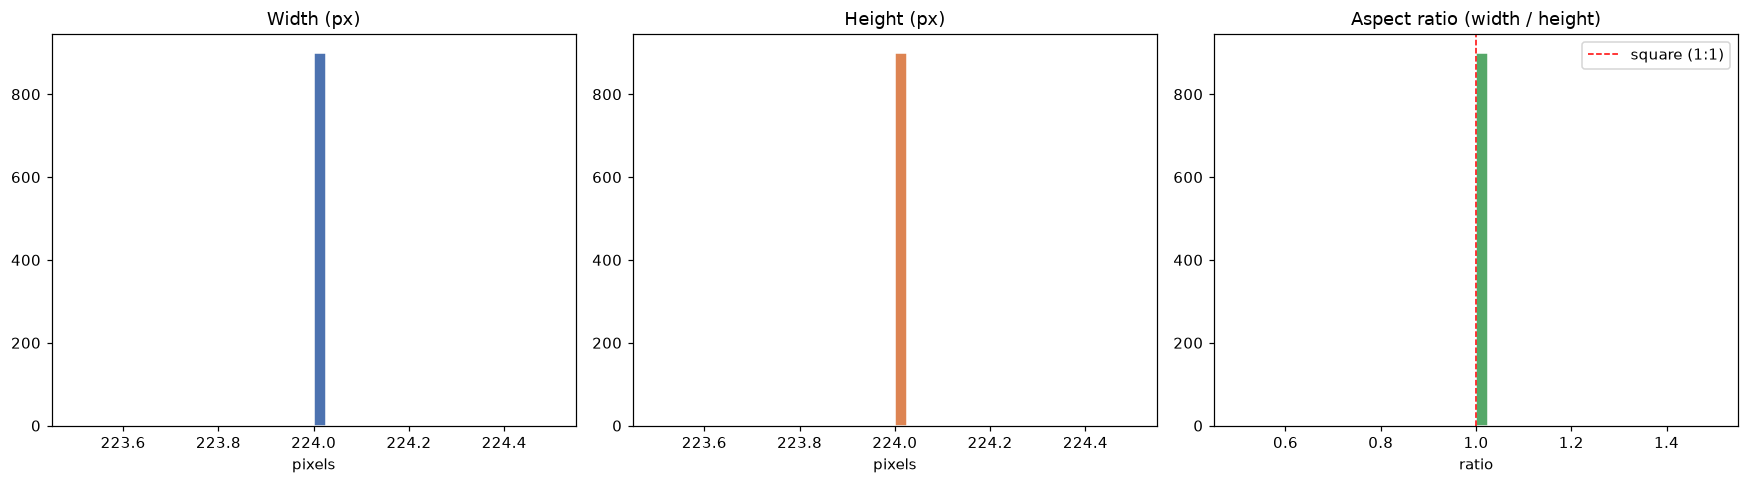

saved -> /mnt/hdd/projects/Vegetables-Classification/reports/figures/01_image_dimensions.png
            min  median  max
split                       
test        1.0     1.0  1.0
train       1.0     1.0  1.0
validation  1.0     1.0  1.0


In [6]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].hist(dim["width"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Width (px)"); axes[0].set_xlabel("pixels")
axes[1].hist(dim["height"], bins=40, color="#DD8452", edgecolor="white")
axes[1].set_title("Height (px)"); axes[1].set_xlabel("pixels")
axes[2].hist(dim["aspect_ratio"], bins=40, color="#55A868", edgecolor="white")
axes[2].set_title("Aspect ratio (width / height)"); axes[2].set_xlabel("ratio")
axes[2].axvline(1.0, color="red", ls="--", lw=1, label="square (1:1)")
axes[2].legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_image_dimensions.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"saved -> {FIGURES_DIR / '01_image_dimensions.png'}")
print(dim.groupby("split")["aspect_ratio"].agg(["min", "median", "max"]).to_string())


## 4) Takeaway: CNN input size

- Images are essentially **square** (aspect ratio ≈ 1.0), so a fixed square input is the right choice.
- The shipped model in `models/vegetable_cnn.h5` expects **150 × 150 × 3** raw RGB pixels — every later notebook uses that size.
- **Next:** `02_preprocessing.ipynb` builds the `tf.data` pipelines.